# 空间可达性分析（医疗设施案例）

本 Notebook 以**医疗设施可达性**为场景，系统演示三种主流空间可达性度量方法：

1. 问题背景与数据概览  
2. 合成城市数据生成  
3. **缓冲区法**（Buffer）  
4. **引力模型**（Gravity Model）  
5. **两步移动搜寻法**（2SFCA）  
6. 方法对比与空间不平等分析  
7. 延伸与复现建议

---

## 阅读目标

- 理解空间可达性度量的三要素：需求点、供给点、阻抗。  
- 掌握缓冲区法、引力模型、2SFCA 的公式与适用场景差异。  
- 能根据数据与研究目标选择合适的可达性方法，并读懂结果图。

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import font_manager
from scipy.spatial.distance import cdist

plt.style.use("seaborn-v0_8-whitegrid")


def configure_matplotlib_chinese() -> None:
    candidates = [
        "PingFang SC",
        "PingFang HK",
        "Hiragino Sans GB",
        "Songti SC",
        "STHeiti",
        "Heiti TC",
        "Arial Unicode MS",
        "Microsoft YaHei",
        "SimHei",
        "Noto Sans CJK SC",
    ]
    installed = {f.name for f in font_manager.fontManager.ttflist}
    for name in candidates:
        if name in installed:
            mpl.rcParams["font.family"] = "sans-serif"
            mpl.rcParams["font.sans-serif"] = [name, "DejaVu Sans", "Arial", "Helvetica"]
            mpl.rcParams["axes.unicode_minus"] = False
            return
    mpl.rcParams["font.sans-serif"] = [*candidates, *mpl.rcParams["font.sans-serif"]]
    mpl.rcParams["axes.unicode_minus"] = False


configure_matplotlib_chinese()


def repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in (cwd, *cwd.parents):
        if (p / "requirements.txt").is_file() and (p / "data").is_dir():
            return p
    return cwd


ROOT = repo_root()
OUT = ROOT / "outputs" / "spatial-accessibility"
OUT.mkdir(parents=True, exist_ok=True)

## 1) 问题背景：为何需要度量空间可达性

设研究区内有 $n$ 个**需求点**（居住地）$\{i\}$，每个需求点有人口 $P_i$；  
同时有 $m$ 个**供给点**（医疗设施）$\{j\}$，每个设施有服务能力 $S_j$（如医生数或床位数）。

最朴素的问题："距离设施最近的居民与最远的居民，公共服务获取有多大差距？"

**空间可达性**（spatial accessibility）通过构造量化指标 $A_i$ 来回答这个问题。不同方法对"距离"和"供需竞争"的处理方式不同，导致结果特征各异。

| 方法 | 距离衰减 | 供需竞争 |
|------|----------|----------|
| 缓冲区法 | 阈值内等权 | 不考虑 |
| 引力模型 | 连续衰减 | 不考虑 |
| 2SFCA | 阈值内等权 | **考虑** |

## 2) 合成城市数据生成

本例使用程序生成的合成城市数据，包含：

- **居住地**（demand points）：100 个区块质心，坐标单位 km，人口由多峰分布给出
- **医疗设施**（supply points）：15 个设施，能力（医生数）服从对数正态分布

合成数据的好处是参数透明可控，便于理解方法本身；真实场景可直接替换为
`geopandas.read_file()` 读入的矢量数据，再提取坐标与属性即可。

In [2]:
rng = np.random.default_rng(42)

# ── 需求点（居住地）──────────────────────────────────────────────────────────
# 城市范围 20×20 km；三个人口集聚核心
centers_pop = np.array([[5.0, 5.0], [14.0, 12.0], [8.0, 16.0]])
weights_pop = [0.5, 0.3, 0.2]

n_demand = 100
idx = rng.choice(len(centers_pop), size=n_demand, p=weights_pop)
demand_xy = centers_pop[idx] + rng.normal(0, 2.5, (n_demand, 2))
demand_xy = np.clip(demand_xy, 0.5, 19.5)
population = rng.integers(500, 5000, size=n_demand).astype(float)

demand = pd.DataFrame(
    {"x": demand_xy[:, 0], "y": demand_xy[:, 1], "population": population}
)

# ── 供给点（医疗设施）─────────────────────────────────────────────────────────
# 设施倾向于布局在城市边缘与中部，刻意制造部分区域"供给洼地"
facility_xy = np.array([
    [3.0, 3.0], [7.0, 2.0], [12.0, 1.5], [17.0, 4.0],
    [2.0, 10.0], [10.0, 8.0], [16.0, 10.0],
    [4.0, 17.0], [11.0, 15.0], [18.0, 17.0],
    [6.0, 12.0], [14.0, 6.0], [9.0, 4.0],
    [15.0, 14.0], [5.5, 8.0],
])
# 部分大医院、部分诊所
capacity = rng.lognormal(mean=2.0, sigma=0.8, size=len(facility_xy))
capacity = np.round(capacity).clip(1, None)

supply = pd.DataFrame(
    {"x": facility_xy[:, 0], "y": facility_xy[:, 1], "capacity": capacity}
)

print(f"需求点：{len(demand)} 个，总人口 {demand['population'].sum():,.0f}")
print(f"设施点：{len(supply)} 个，总能力 {supply['capacity'].sum():.0f} 医生/床位")
print(f"\n需求点（前5行）：\n{demand.head()}")
print(f"\n设施点（前5行）：\n{supply.head()}")

需求点：100 个，总人口 287,426
设施点：15 个，总能力 149 医生/床位

需求点（前5行）：
           x          y  population
0  14.999436   9.736302      2451.0
1   4.054594   8.248071      2650.0
2   7.109340  17.843789      1243.0
3  11.665956  11.486406      2376.0
4   2.624945   4.152417      3218.0

设施点（前5行）：
      x     y  capacity
0   3.0   3.0       5.0
1   7.0   2.0      12.0
2  12.0   1.5       2.0
3  17.0   4.0      24.0
4   2.0  10.0      10.0


### 2.1 城市概览图

在可达性分析前，先绘制需求点与设施点的空间分布，检验数据是否合理，并建立空间直觉：
- **点大小**对应人口规模
- **设施形状**（★）对应服务能力

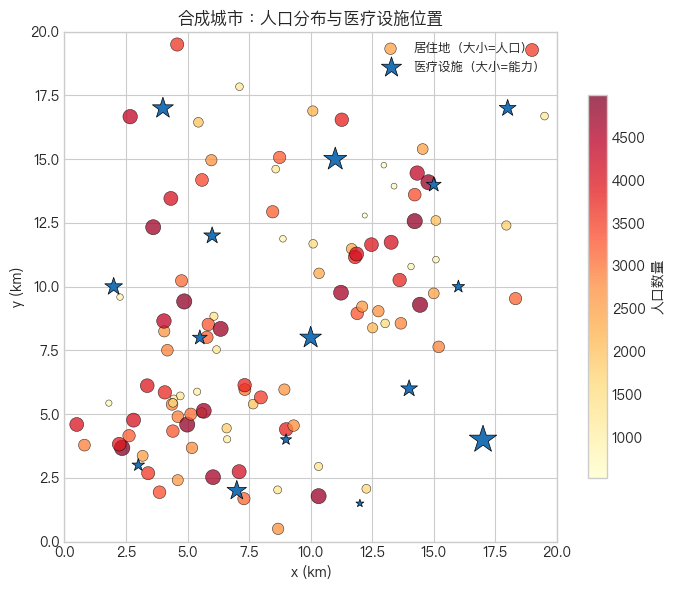

In [3]:
fig, ax = plt.subplots(figsize=(7, 6))

sc = ax.scatter(
    demand["x"], demand["y"],
    s=demand["population"] / 40,
    c=demand["population"],
    cmap="YlOrRd",
    alpha=0.75,
    edgecolors="k",
    linewidths=0.4,
    label="居住地（大小=人口）",
    zorder=2,
)
plt.colorbar(sc, ax=ax, shrink=0.75, label="人口数量")

ax.scatter(
    supply["x"], supply["y"],
    s=supply["capacity"] * 18,
    marker="*",
    c="#2171b5",
    edgecolors="k",
    linewidths=0.5,
    label="医疗设施（大小=能力）",
    zorder=3,
)

ax.set_xlim(0, 20)
ax.set_ylim(0, 20)
ax.set_xlabel("x (km)")
ax.set_ylabel("y (km)")
ax.set_title("合成城市：人口分布与医疗设施位置")
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
fig.savefig(OUT / "city_overview.png", dpi=150)
plt.show()

## 3) 缓冲区法（Buffer Method）

**公式**：

$$
A_i^{\text{buffer}} = \sum_{j:\, d_{ij} \le d_0} S_j
$$

阈值距离 $d_0$ 内的设施能力求和。超出阈值贡献为零。

**参数**：$d_0$（km，欧氏距离）。

In [4]:
# 计算需求点与设施之间的欧氏距离矩阵 (n_demand × n_supply)
demand_coords = demand[["x", "y"]].to_numpy()
supply_coords = supply[["x", "y"]].to_numpy()

dist_matrix = cdist(demand_coords, supply_coords)   # 单位：km

# 缓冲区法
d0 = 5.0   # km

def buffer_accessibility(dist_matrix, supply_capacity, threshold):
    # 阈值内设施能力加总
    within = dist_matrix <= threshold
    return (within * supply_capacity[np.newaxis, :]).sum(axis=1)


demand["A_buffer"] = buffer_accessibility(dist_matrix, supply["capacity"].to_numpy(), d0)

print(f"缓冲区阈值 d0 = {d0} km")
print(demand[["x", "y", "population", "A_buffer"]].describe().round(2))

缓冲区阈值 d0 = 5.0 km
            x       y  population  A_buffer
count  100.00  100.00      100.00    100.00
mean     8.42    8.67     2874.26     27.88
std      4.54    4.62     1222.64      9.93
min      0.50    0.50      535.00      5.00
25%      4.61    4.86     1938.50     22.00
50%      7.32    8.54     2903.00     28.00
75%     12.21   11.99     3809.25     36.00
max     19.50   19.50     4984.00     45.00


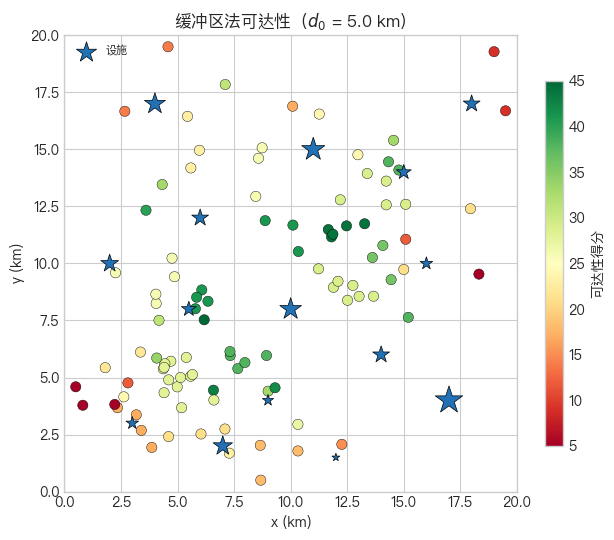

In [5]:
def plot_accessibility(demand_df, col, title, cmap="RdYlGn", ax=None, fig=None,
                          supply_df=None, standalone=True):
    # 通用可达性分布图
    if standalone:
        fig, ax = plt.subplots(figsize=(6.5, 5.5))
    sc = ax.scatter(
        demand_df["x"], demand_df["y"],
        c=demand_df[col],
        cmap=cmap,
        s=55,
        edgecolors="k",
        linewidths=0.3,
        zorder=2,
    )
    plt.colorbar(sc, ax=ax, shrink=0.8, label="可达性得分")
    if supply_df is not None:
        ax.scatter(
            supply_df["x"], supply_df["y"],
            marker="*", s=supply_df["capacity"] * 18,
            c="#2171b5", edgecolors="k", linewidths=0.5,
            label="设施", zorder=3,
        )
        ax.legend(fontsize=8)
    ax.set_xlim(0, 20)
    ax.set_ylim(0, 20)
    ax.set_xlabel("x (km)")
    ax.set_ylabel("y (km)")
    ax.set_title(title)
    return fig, ax


fig, ax = plot_accessibility(
    demand, "A_buffer",
    f"缓冲区法可达性（$d_0$ = {d0} km）",
    supply_df=supply,
)
fig.tight_layout()
fig.savefig(OUT / "buffer_accessibility.png", dpi=150)
plt.show()

## 4) 引力模型（Gravity Model）

**公式**：

$$
A_i^{\text{gravity}} = \sum_j \frac{S_j}{d_{ij}^\beta}
$$

- $\beta$：距离摩擦系数，越大则近处设施权重越高
- $d_{ij} = 0$ 时用一个小量 $\epsilon$ 截断，避免除以零

引力模型用**连续**的距离衰减权重，避免了缓冲区的边界突变。

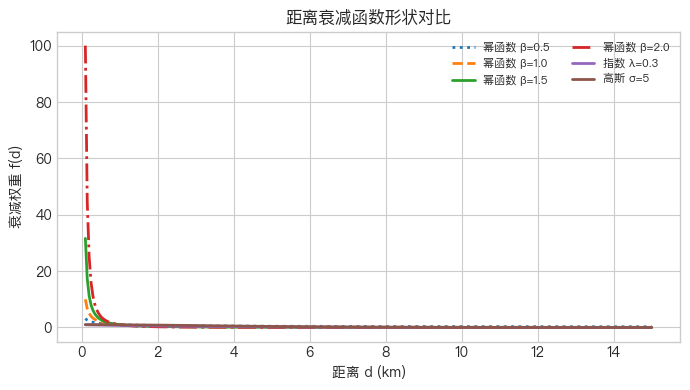

In [6]:
# 距离衰减函数示意
h = np.linspace(0.1, 15, 300)

fig, ax = plt.subplots(figsize=(7, 4))
for beta, ls in [(0.5, ":"), (1.0, "--"), (1.5, "-"), (2.0, "-.")]:
    ax.plot(h, 1.0 / h**beta, ls, lw=2, label=f"幂函数 β={beta}")
ax.plot(h, np.exp(-0.3 * h), lw=2, label="指数 λ=0.3")
ax.plot(h, np.exp(-(h / 5) ** 2), lw=2, label="高斯 σ=5")
ax.set_xlabel("距离 d (km)")
ax.set_ylabel("衰减权重 f(d)")
ax.set_title("距离衰减函数形状对比")
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
fig.savefig(OUT / "decay_functions.png", dpi=150)
plt.show()

In [7]:
def gravity_accessibility(dist_matrix, supply_capacity, beta, eps=0.1):
    # 幂函数衰减引力模型。eps 为距离截断（km），避免零距离除法
    d = np.maximum(dist_matrix, eps)
    weights = 1.0 / d**beta
    return (weights * supply_capacity[np.newaxis, :]).sum(axis=1)


beta = 1.5
demand["A_gravity"] = gravity_accessibility(dist_matrix, supply["capacity"].to_numpy(), beta)

print(f"引力模型（β={beta}）统计：")
print(demand["A_gravity"].describe().round(4))

引力模型（β=1.5）统计：
count    100.0000
mean      12.8962
std        8.9935
min        5.1770
25%        9.3361
50%       10.8315
75%       12.2553
max       68.0677
Name: A_gravity, dtype: float64


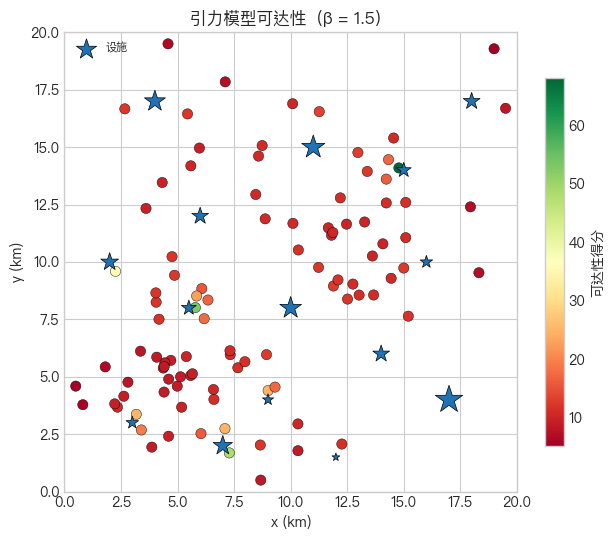

In [8]:
fig, ax = plot_accessibility(
    demand, "A_gravity",
    f"引力模型可达性（β = {beta}）",
    supply_df=supply,
)
fig.tight_layout()
fig.savefig(OUT / "gravity_accessibility.png", dpi=150)
plt.show()

## 5) 两步移动搜寻法（2SFCA）

**两步算法**：

**第一步** — 从**设施** $j$ 出发，计算其服务区内的供需比：

$$
R_j = \frac{S_j}{\displaystyle\sum_{k:\, d_{kj} \le d_0} P_k}
$$

若服务区内无人口，则 $R_j = 0$（或设为 NaN）。

**第二步** — 从**需求点** $i$ 出发，汇总其可达圈内所有设施的供需比：

$$
A_i^{\text{2SFCA}} = \sum_{j:\, d_{ij} \le d_0} R_j
$$

$A_i$ 的单位：医生数 / 千人（若 $S_j$ 为医生数，$P_k$ 为人口数）。

In [9]:
def sfca_accessibility(dist_matrix, supply_capacity, population, threshold):
    # 两步移动搜寻法（2SFCA）
    # dist_matrix : (n_demand, n_supply)
    # supply_capacity : (n_supply,)  设施服务能力
    # population : (n_demand,)       需求点人口
    # threshold : 搜寻半径（km）
    # 返回 A (n_demand,) 可达性得分，R (n_supply,) 供需比
    n_demand, n_supply = dist_matrix.shape

    # 第一步：计算每个设施的供需比 R_j
    R = np.zeros(n_supply)
    for j in range(n_supply):
        catchment = dist_matrix[:, j] <= threshold
        total_pop = population[catchment].sum()
        if total_pop > 0:
            R[j] = supply_capacity[j] / total_pop

    # 第二步：对每个需求点汇总其可达圈内的 R_j
    A = np.zeros(n_demand)
    for i in range(n_demand):
        reachable = dist_matrix[i, :] <= threshold
        A[i] = R[reachable].sum()

    return A, R


d0_sfca = 5.0   # km，与缓冲区阈值相同，便于对比

demand["A_sfca"], supply["R_sfca"] = sfca_accessibility(
    dist_matrix,
    supply["capacity"].to_numpy(),
    demand["population"].to_numpy(),
    threshold=d0_sfca,
)

print(f"2SFCA（d0={d0_sfca} km）统计：")
print(demand["A_sfca"].describe().round(6))
print(f"\n供需比 R_j（单位：医生/人，部分设施）：")
print(supply[["x", "y", "capacity", "R_sfca"]].head(8).round(6))

2SFCA（d0=5.0 km）统计：
count    100.000000
mean       0.000516
std        0.000850
min        0.000054
25%        0.000288
50%        0.000421
75%        0.000573
max        0.008704
Name: A_sfca, dtype: float64

供需比 R_j（单位：医生/人，部分设施）：
      x     y  capacity    R_sfca
0   3.0   3.0       5.0  0.000054
1   7.0   2.0      12.0  0.000118
2  12.0   1.5       2.0  0.000093
3  17.0   4.0      24.0  0.008418
4   2.0  10.0      10.0  0.000201
5  10.0   8.0      15.0  0.000168
6  16.0  10.0       5.0  0.000063
7   4.0  17.0      14.0  0.000538


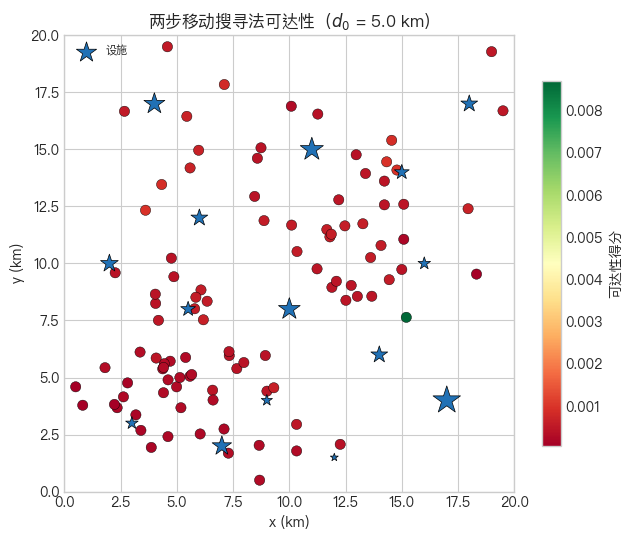

In [10]:
fig, ax = plot_accessibility(
    demand, "A_sfca",
    f"两步移动搜寻法可达性（$d_0$ = {d0_sfca} km）",
    supply_df=supply,
)
fig.tight_layout()
fig.savefig(OUT / "sfca_accessibility.png", dpi=150)
plt.show()

## 6) 方法对比与空间不平等分析

### 6.1 三种方法并排可视化

直观比较三种方法在同一数据下的空间分布差异。

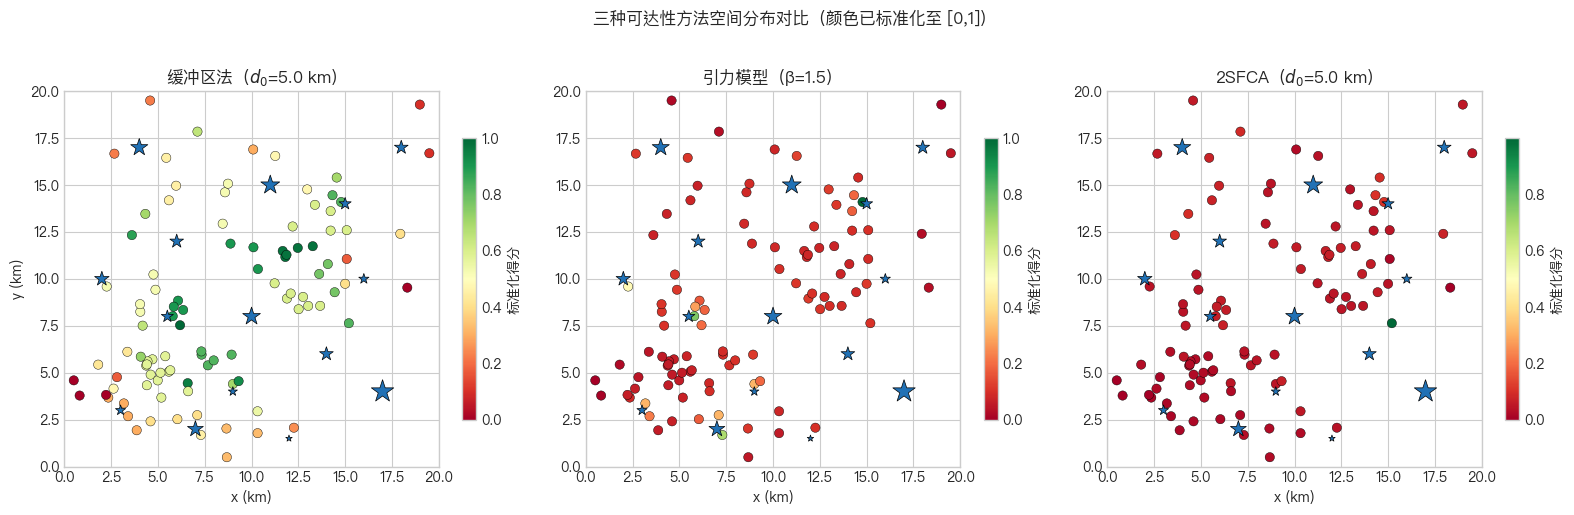

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
configs = [
    ("A_buffer",  f"缓冲区法（$d_0$={d0} km）",   "buffer_accessibility"),
    ("A_gravity", f"引力模型（β={beta}）",          "gravity_accessibility"),
    ("A_sfca",    f"2SFCA（$d_0$={d0_sfca} km）",  "sfca_accessibility"),
]

for ax, (col, title, _) in zip(axes, configs):
    vals = demand[col]
    sc = ax.scatter(
        demand["x"], demand["y"],
        c=(vals - vals.min()) / (vals.max() - vals.min() + 1e-12),  # 0-1 标准化
        cmap="RdYlGn",
        s=45,
        edgecolors="k",
        linewidths=0.3,
        zorder=2,
    )
    ax.scatter(
        supply["x"], supply["y"],
        marker="*", s=supply["capacity"] * 12,
        c="#2171b5", edgecolors="k", linewidths=0.5, zorder=3,
    )
    ax.set_xlim(0, 20)
    ax.set_ylim(0, 20)
    ax.set_xlabel("x (km)")
    ax.set_title(title)
    plt.colorbar(sc, ax=ax, shrink=0.75, label="标准化得分")

axes[0].set_ylabel("y (km)")
fig.suptitle("三种可达性方法空间分布对比（颜色已标准化至 [0,1]）", y=1.02)
fig.tight_layout()
fig.savefig(OUT / "method_comparison_maps.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.2 方法间相关性

三种方法在同一区域上结果是否一致？若相关性高，说明它们"描述同一现象"；  
若相关性低，则各方法捕捉到了可达性的不同侧面。

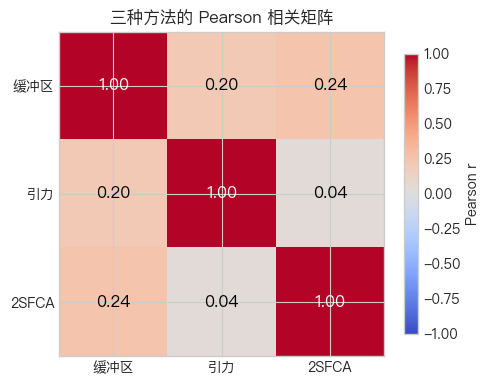


相关矩阵：
          缓冲区     引力  2SFCA
缓冲区    1.000  0.204  0.244
引力     0.204  1.000  0.037
2SFCA  0.244  0.037  1.000


In [12]:
cols = ["A_buffer", "A_gravity", "A_sfca"]
labels = ["缓冲区", "引力", "2SFCA"]

corr_df = demand[cols].rename(columns=dict(zip(cols, labels))).corr()

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr_df.values, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.85, label="Pearson r")
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{corr_df.values[i, j]:.2f}", ha="center", va="center",
                fontsize=12, color="black" if abs(corr_df.values[i, j]) < 0.7 else "white")
ax.set_title("三种方法的 Pearson 相关矩阵")
fig.tight_layout()
fig.savefig(OUT / "method_comparison.png", dpi=150)
plt.show()

print("\n相关矩阵：\n", corr_df.round(3))

### 6.3 空间不平等：变异系数（CV）

$$
\text{CV} = \frac{\sigma(A)}{\mu(A)}
$$

CV 越大，表示不同居民之间的可达性差异越大（越不公平）。  
注意：比较 CV 时，应确保各方法得分在相同尺度或已标准化。

In [13]:
ineq = {}
for col, label in zip(cols, labels):
    arr = demand[col].to_numpy()
    # 人口加权变异系数（更准确反映居民感受）
    weights = demand["population"].to_numpy()
    mu_w = np.average(arr, weights=weights)
    sigma_w = np.sqrt(np.average((arr - mu_w) ** 2, weights=weights))
    ineq[label] = {"均值（人口加权）": mu_w, "标准差（加权）": sigma_w,
                   "变异系数 CV": sigma_w / mu_w if mu_w > 0 else np.nan}

print("空间不平等指标（人口加权）：\n")
ineq_df = pd.DataFrame(ineq).T
print(ineq_df.to_string())

空间不平等指标（人口加权）：

        均值（人口加权）    标准差（加权）   变异系数 CV
缓冲区    27.843549  10.208055  0.366622
引力     13.321600  10.023916  0.752456
2SFCA   0.000518   0.000846  1.631252


## 7) 延伸与复现建议

1. **敏感性分析**：修改 `d0`（如 3 km、7 km），观察缓冲区法和 2SFCA 结果变化幅度，对比引力模型（无阈值）的稳定性。
2. **调整 β**：将引力模型的 `beta` 从 1.5 改为 1.0 或 2.0，观察城市中心与边缘的可达性差异如何变化。
3. **增强型 2SFCA（E2SFCA）**：在 `sfca_accessibility` 两步中均引入高斯权重 $W(d) = e^{-(d/\sigma)^2}$，替代 0-1 阈值，观察边界处的平滑效果。
4. **真实数据替换**：将 `demand`/`supply` 替换为用 `geopandas` 读入的城市街道级人口普查数据和 POI（兴趣点）数据，其余代码逻辑不变。
5. **路网距离**：用 `osmnx.distance.nearest_edges` + `networkx.shortest_path_length` 得到路网距离矩阵，替换 `dist_matrix`，观察与欧氏距离结果的差异。

---

### 产出图件（`outputs/spatial-accessibility/`）

| 文件 | 内容 |
|------|------|
| `city_overview.png` | 合成城市：人口与设施分布 |
| `decay_functions.png` | 距离衰减函数形状对比 |
| `buffer_accessibility.png` | 缓冲区法可达性分布 |
| `gravity_accessibility.png` | 引力模型可达性分布 |
| `sfca_accessibility.png` | 2SFCA 可达性分布 |
| `method_comparison_maps.png` | 三种方法并排对比（标准化） |
| `method_comparison.png` | 方法间 Pearson 相关矩阵 |